In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from skimpy import clean_columns

/Users/chloecho/anaconda3/envs/cornell_dev/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [10]:
soil_intake = pd.read_csv('soil_intake.csv')
soil_intake = clean_columns(soil_intake)
soil_intake

,sample_id,project,site,field_id,collection_date,treatment,notes,nitrogen_testing,sample_dried_y_n,sample_ground_y_n,emily_shipping,sample_sent_for_processing_y_n,where_samples_were_sent
0,25_SN_1058,R,NaN,CER_DEL_1,5/20/25,F,NaN,Y,Y,Y,NaN,NaN,NaN
1,25_SN_1059,R,NaN,CER_DEL_1,5/20/25,N,NaN,Y,Y,Y,NaN,NaN,NaN
2,25_SN_1417,R,NaN,CER_DEL_1,12/1/25,NEONIC,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25_SN_1418,R,NaN,CER_DEL_1,12/1/25,FUNG,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,25_SN_1060,R,NaN,CER_DEL_2,5/20/25,F,NaN,Y,Y,Y,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,25_SN_1248,R,NaN,ZUE_MYT,8/12/25,NEONIC,Harvest,Y,Y,NaN,NaN,NaN,NaN
211,25_SN_1222,R,NaN,ZUE_VOT,8/14/25,NEONIC,Harvest,Y,Y,NaN,NaN,NaN,NaN
212,25_SN_1234,R,NaN,ZUE_VOT,6/27/25,NEONIC,NaN,Y,Y,NaN,NaN,NaN,NaN
213,25_SN_1235,R,NaN,ZUE_VOT,6/27/25,FUNG,NaN,Y,Y,NaN,NaN,NaN,NaN


In [11]:
soil_data = pd.read_csv('scm_soil_nitrogen.csv')
soil_data = clean_columns(soil_data)
soil_data

,number,sample_id,ammonium,nitrate_nitrite
0,1,25_SN_1008,77.1,2.0
1,2,25_SN_1009,99.1,5.4
2,3,25_SN_1010,60.0,3.1
3,4,25_SN_1011,23.4,1.7
4,5,25_SN_1012,39.4,1.4
...,...,...,...,...
192,156,25_SN_1288,22.8,38.0
193,157,25_SN_1289,21.3,16.9
194,158,25_SN_1290,53.2,4.4
195,159,25_SN_1291,39.3,5.2


In [12]:
soil_data = soil_data.merge(soil_intake, on='sample_id')
soil_data

,number,sample_id,ammonium,nitrate_nitrite,project,site,field_id,collection_date,treatment,notes,nitrogen_testing,sample_dried_y_n,sample_ground_y_n,emily_shipping,sample_sent_for_processing_y_n,where_samples_were_sent
0,2,25_SN_1009,99.1,5.4,R,NaN,DEG_FOU,4/28/25,NaN,arrived frozen,Y,Y,Y,NaN,N,NaN
1,6,25_SN_1013,36.8,6.8,R,NaN,DEG_FOU,4/28/25,NaN,arrived frozen,Y,Y,Y,NaN,N,NaN
2,8,25_SN_1015,26.1,1.6,R,NaN,DEG_LAF_1,4/28/25,NaN,arrived frozen,Y,Y,Y,NaN,N,NaN
3,9,25_SN_1029,39.9,3.6,R,NaN,DEG_FRI,5/11/25,NaN,NaN,Y,Y,Y,NaN,NaN,NaN
4,10,25_SN_1030,35.0,4.9,R,NaN,DEG_FRI,5/11/25,NaN,NaN,Y,Y,Y,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,156,25_SN_1288,22.8,38.0,R,NaN,STA_WIL,10/27/25,FUNG,NaN,Y,Y,NaN,NaN,NaN,NaN
188,157,25_SN_1289,21.3,16.9,R,NaN,STA_WIL,10/27/25,NEONIC,NaN,Y,Y,NaN,NaN,NaN,NaN
189,158,25_SN_1290,53.2,4.4,R,NaN,SMI_HOF_2,11/8/25,FUNG,NaN,Y,NaN,NaN,NaN,NaN,NaN
190,159,25_SN_1291,39.3,5.2,R,NaN,SMI_HOF_2,11/8/25,NEONIC,NaN,Y,Y,NaN,NaN,NaN,NaN


In [15]:
soil_data = soil_data[['sample_id', 'ammonium', 'nitrate_nitrite', 'field_id', 'collection_date']]
soil_data

,sample_id,ammonium,nitrate_nitrite,field_id,collection_date
0,25_SN_1009,99.1,5.4,DEG_FOU,4/28/25
1,25_SN_1013,36.8,6.8,DEG_FOU,4/28/25
2,25_SN_1015,26.1,1.6,DEG_LAF_1,4/28/25
3,25_SN_1029,39.9,3.6,DEG_FRI,5/11/25
4,25_SN_1030,35.0,4.9,DEG_FRI,5/11/25
...,...,...,...,...,...
187,25_SN_1288,22.8,38.0,STA_WIL,10/27/25
188,25_SN_1289,21.3,16.9,STA_WIL,10/27/25
189,25_SN_1290,53.2,4.4,SMI_HOF_2,11/8/25
190,25_SN_1291,39.3,5.2,SMI_HOF_2,11/8/25


In [17]:
soil_data.groupby('field_id')

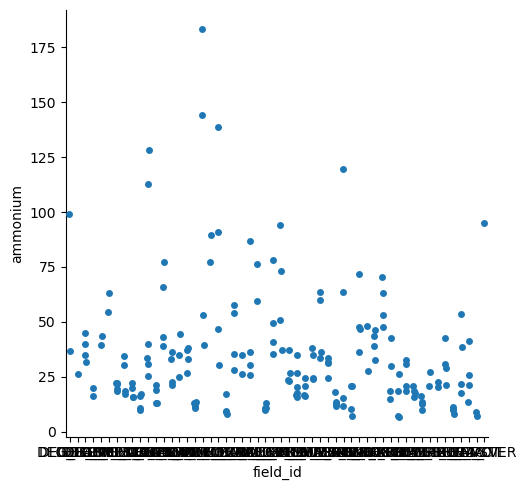

In [19]:
sns.catplot(data=soil_data, x='field_id', y='ammonium')

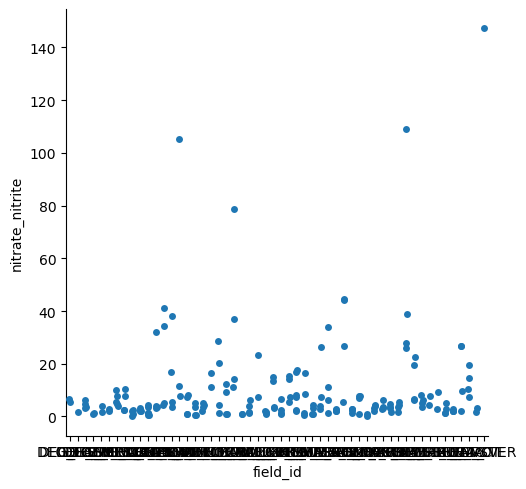

In [20]:
sns.catplot(data=soil_data, x='field_id', y='nitrate_nitrite')

In [21]:
soil_data.loc[soil_data['nitrate_nitrite'] > 60]

,sample_id,ammonium,nitrate_nitrite,field_id,collection_date
105,25_SN_1426,28.2,78.6,MIL_CRO_2,10/1/25
154,25_SN_1223,32.5,108.9,KIK_MBF,8/26/25
173,25_SN_1242,95.1,147.2,LET_ VER,8/29/25
177,25_SN_1246,24.9,105.3,LET_VER,8/29/25
